## **Assignment 02**

#### **01. Blob Detection**

In [1]:
#import required libraries
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace, maximum_filter

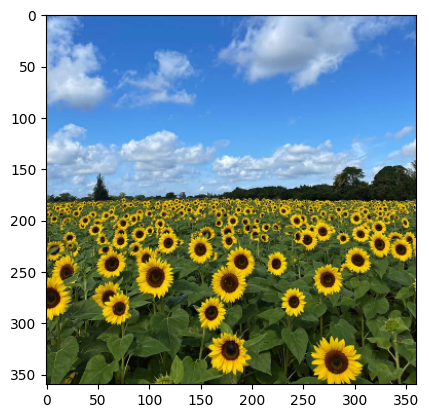

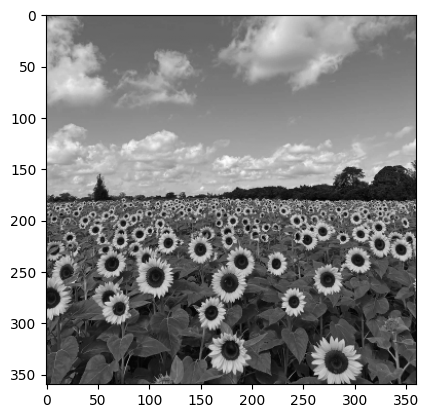

In [2]:
#Read image reducing resolution by factor 4
sunflower_img = cv.imread('the_berry_farms_sunflower_field.jpeg', cv.IMREAD_REDUCED_COLOR_4) 
plt.imshow(sunflower_img[:,:,::-1])
plt.show()

#Convert the image into GrayScale
sunflower_gray = cv.cvtColor(sunflower_img, cv.COLOR_BGR2GRAY) / 255
plt.imshow(sunflower_gray, cmap='gray')
plt.show()

**Gaussian Filter derivation**

In [4]:
X, Y = np.meshgrid(np.arange(-2,3), np.arange(-2,3))
sigma = 1
gaussian = (1/(2*np.pi*sigma**2))*np.exp(-(X**2+Y**2)/(2*sigma**2))
min =np.min((gaussian))
print(np.round(gaussian/min).astype(int))

[[ 1  4  7  4  1]
 [ 4 20 33 20  4]
 [ 7 33 55 33  7]
 [ 4 20 33 20  4]
 [ 1  4  7  4  1]]


In [5]:
G = []
margins = [-2.5,-1.5, -0.5, 0.5, 1.5,2.5]
for j in range(5):
  g = [] 
  for i in range(5):
    X, Y = np.meshgrid(np.arange(margins[i],margins[i+1]+0.001,0.001), np.arange(margins[j],margins[j+1]+0.001,0.001))
    sigma = 1
    gaussian = (1/(2*np.pi*sigma**2))*np.exp(-(X**2+Y**2)/(2*sigma**2))
    g.append(np.sum(gaussian))
  G.append(g)

print(np.round(G/np.min(G)).astype(int))


[[ 1  4  6  4  1]
 [ 4 16 25 16  4]
 [ 6 25 40 25  6]
 [ 4 16 25 16  4]
 [ 1  4  6  4  1]]


### **Blob Detection (Method 01)**

[np.float64(1.0), np.float64(1.4142135623730951), np.float64(2.0000000000000004), np.float64(2.8284271247461907), np.float64(4.000000000000001), np.float64(5.656854249492382), np.float64(8.000000000000004), np.float64(11.313708498984766)]


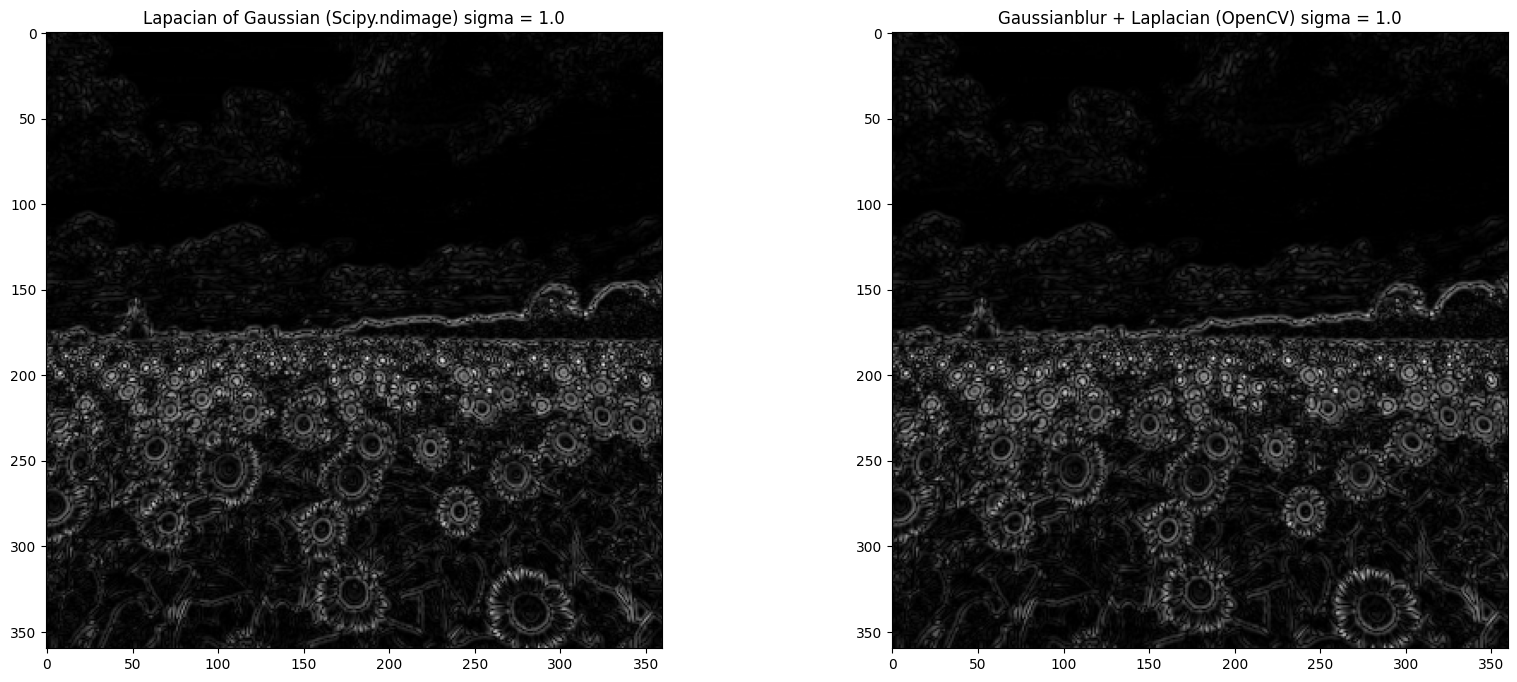

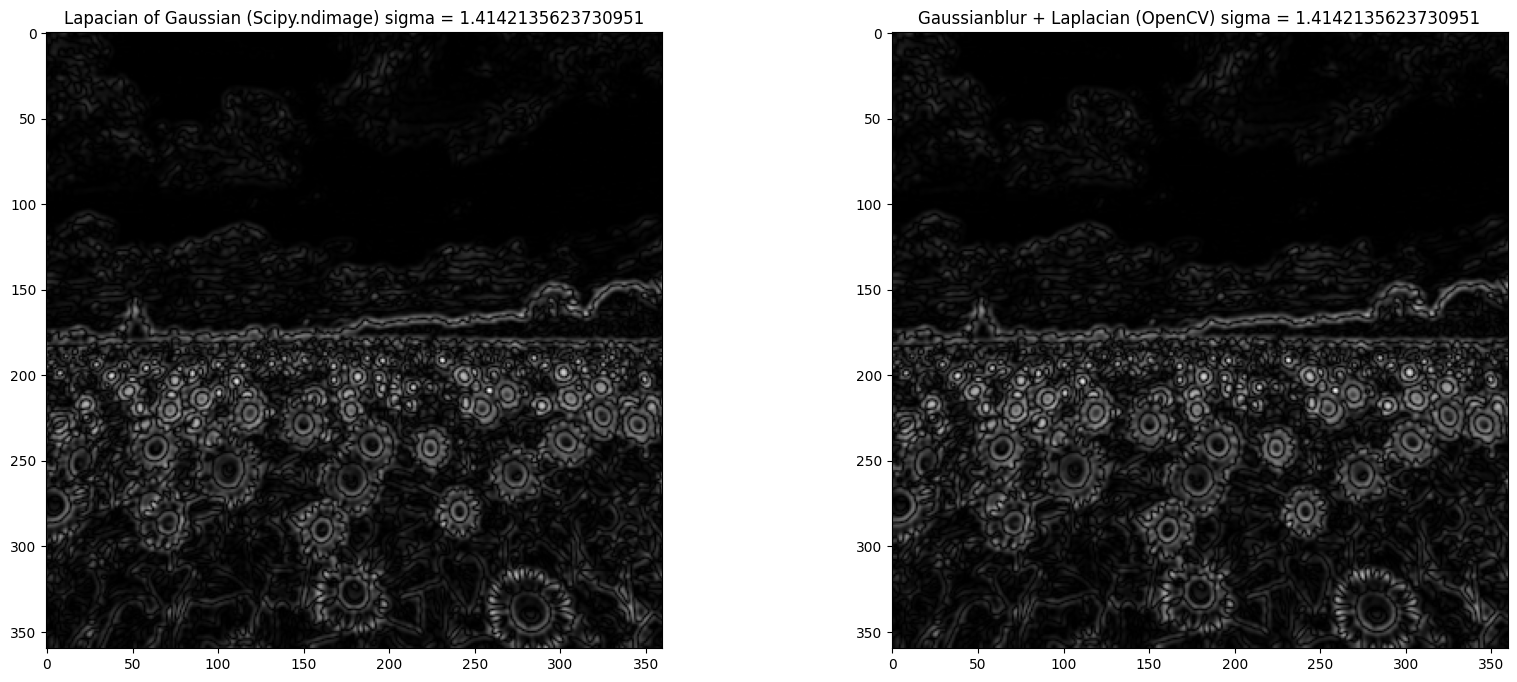

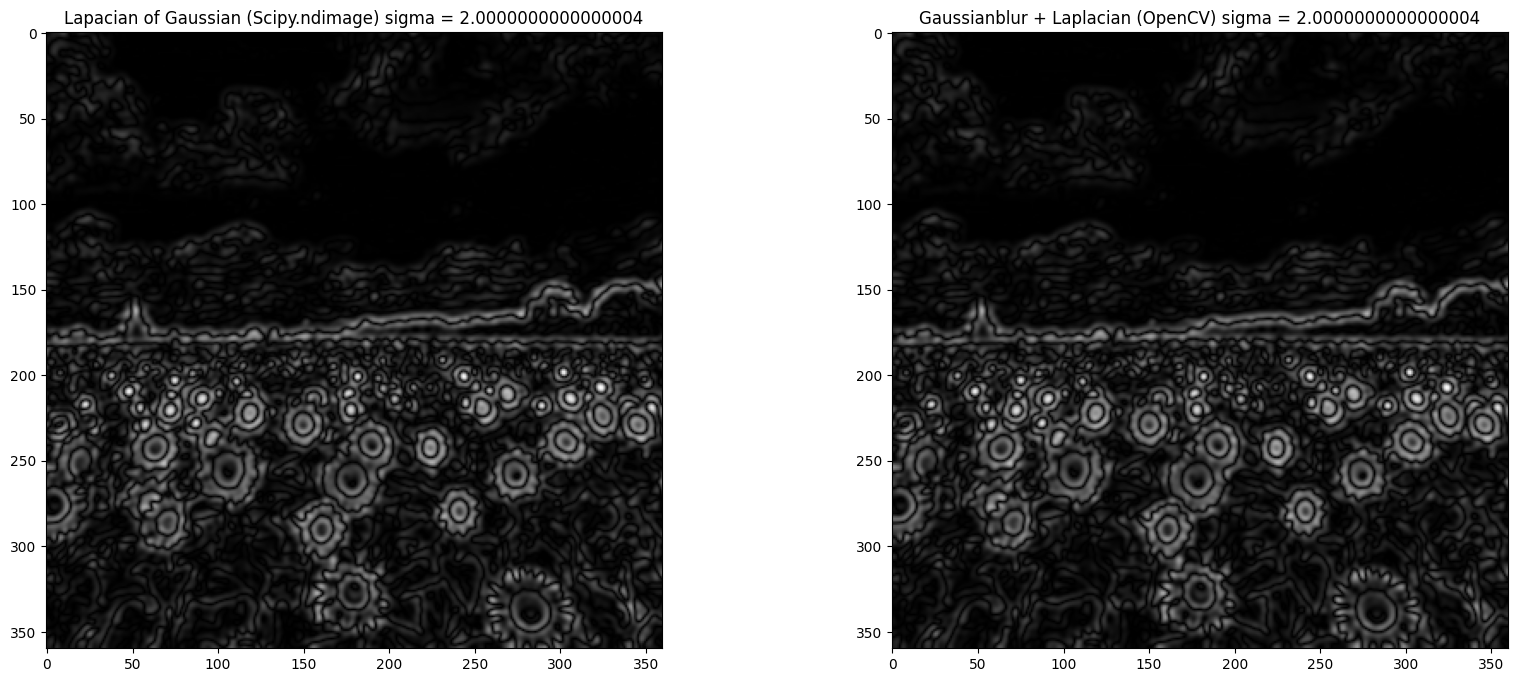

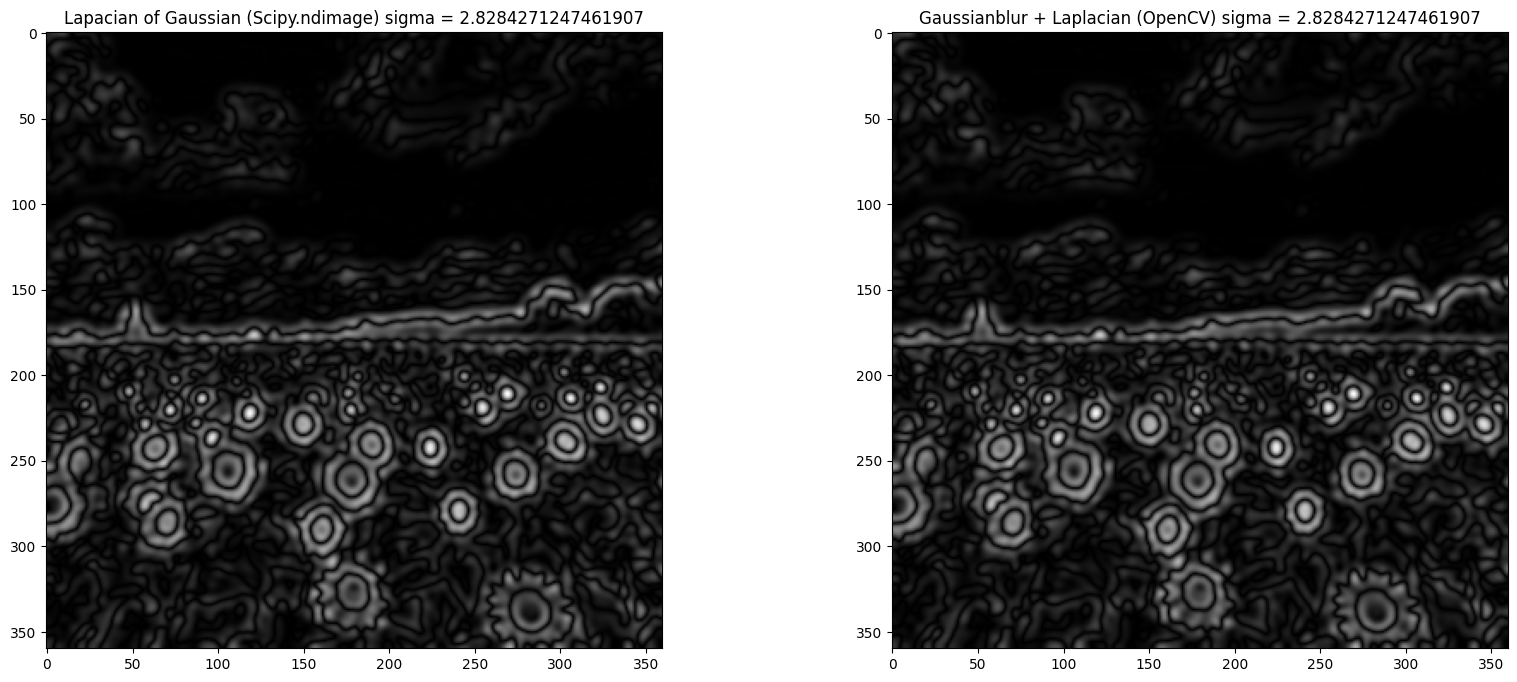

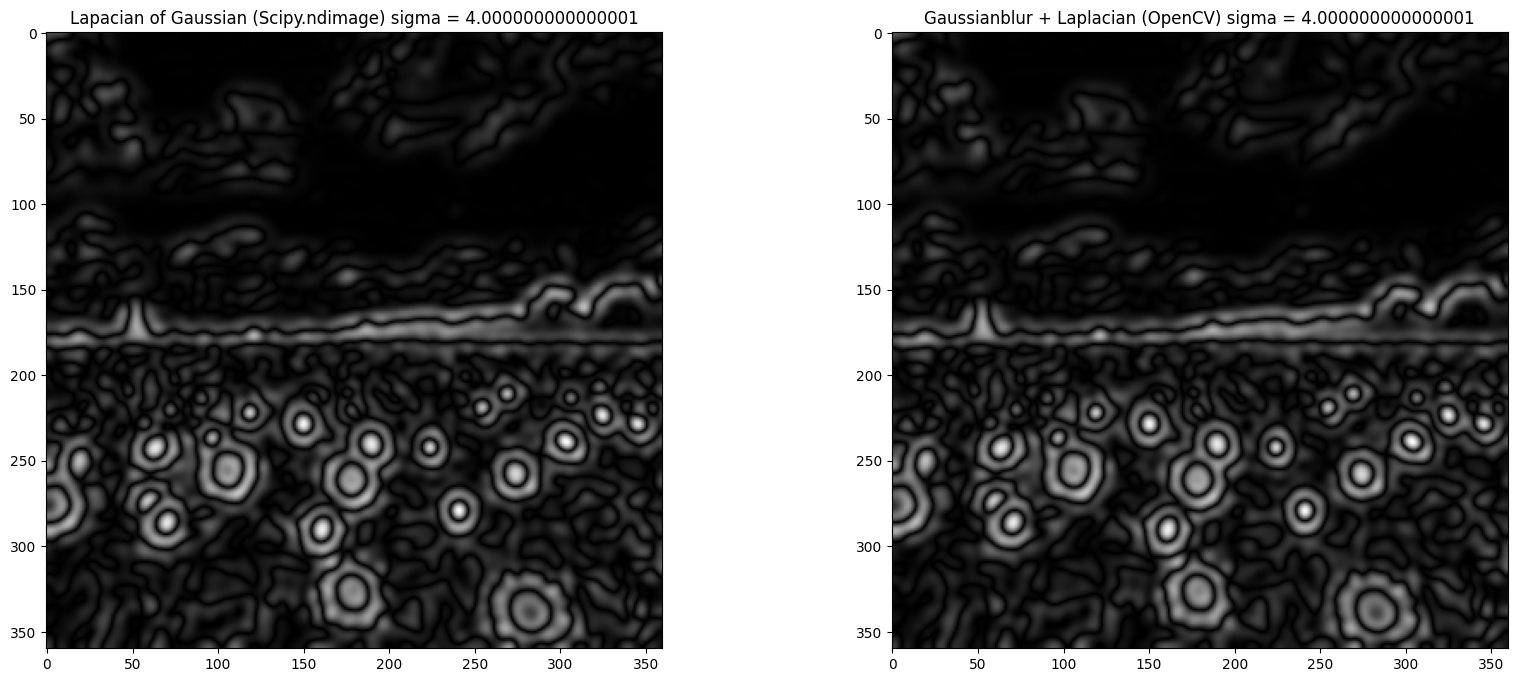

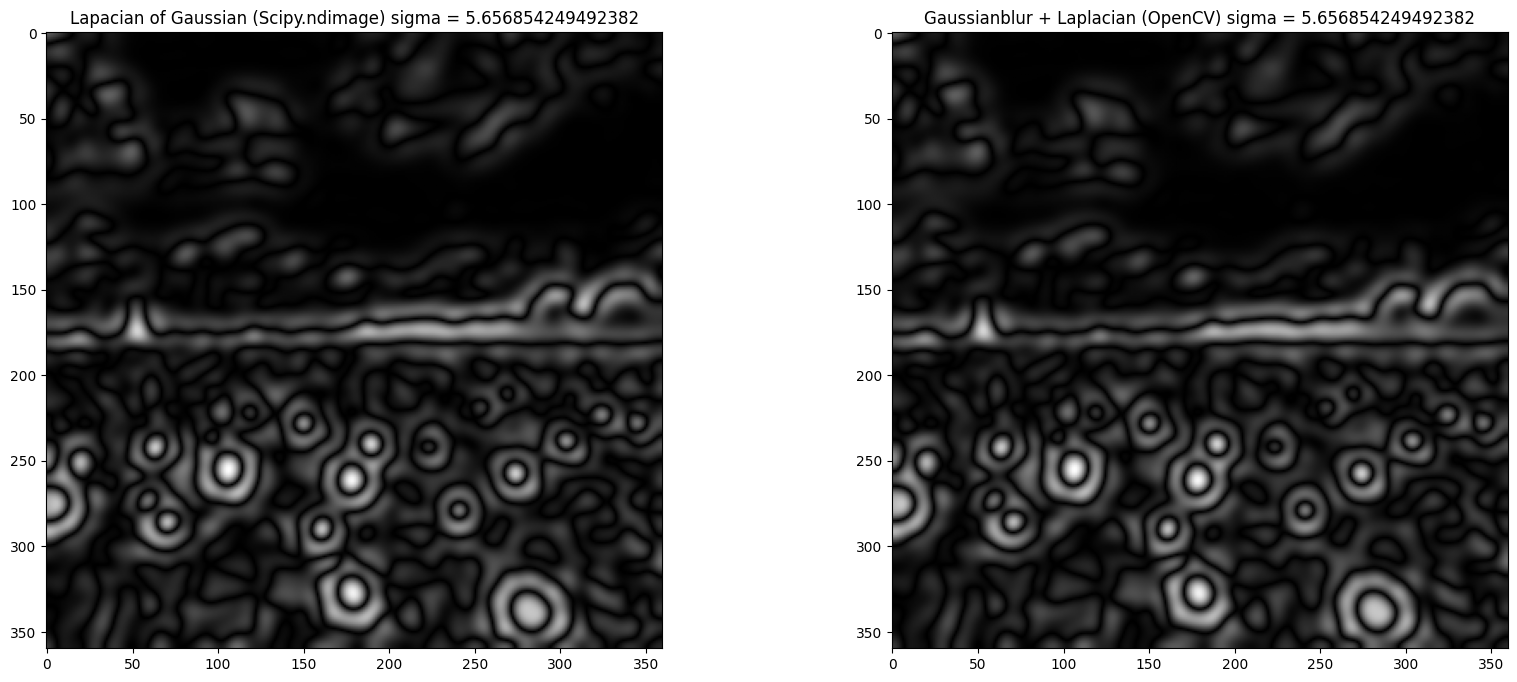

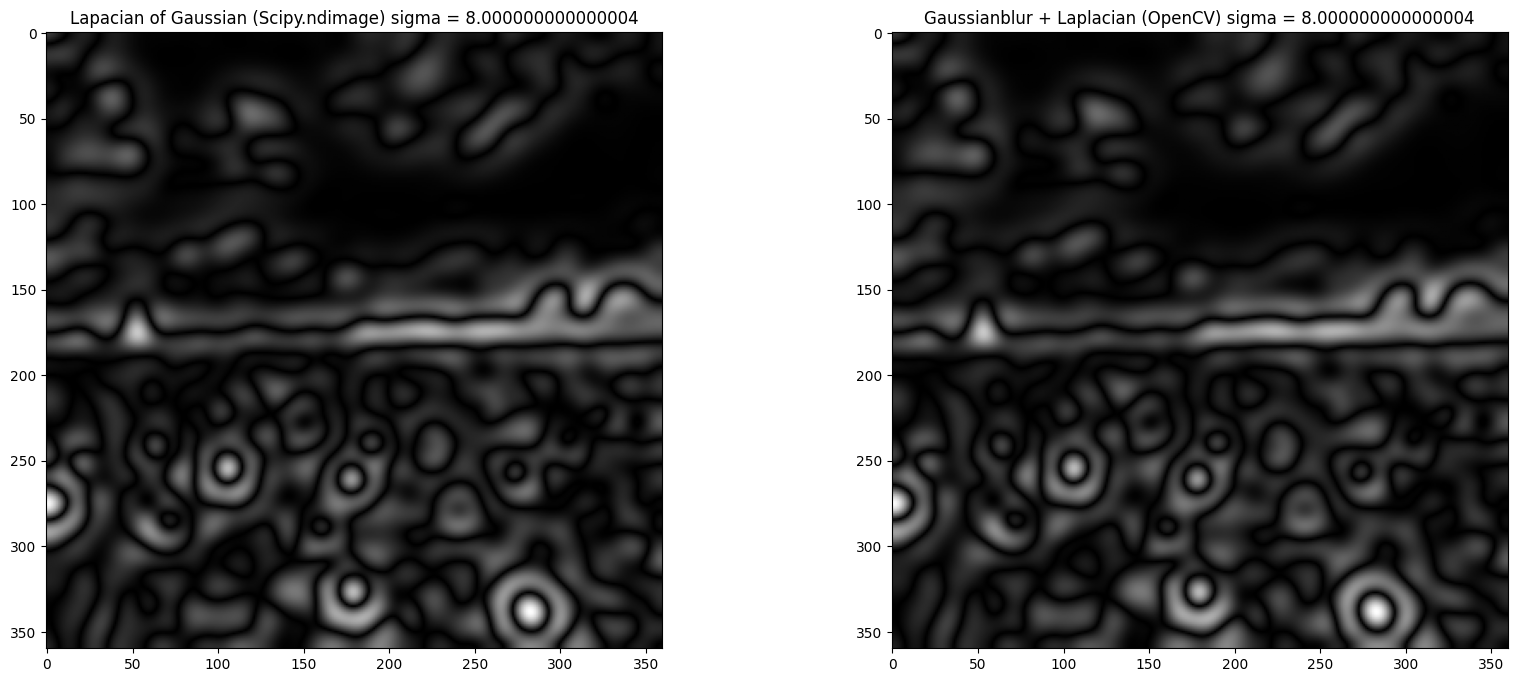

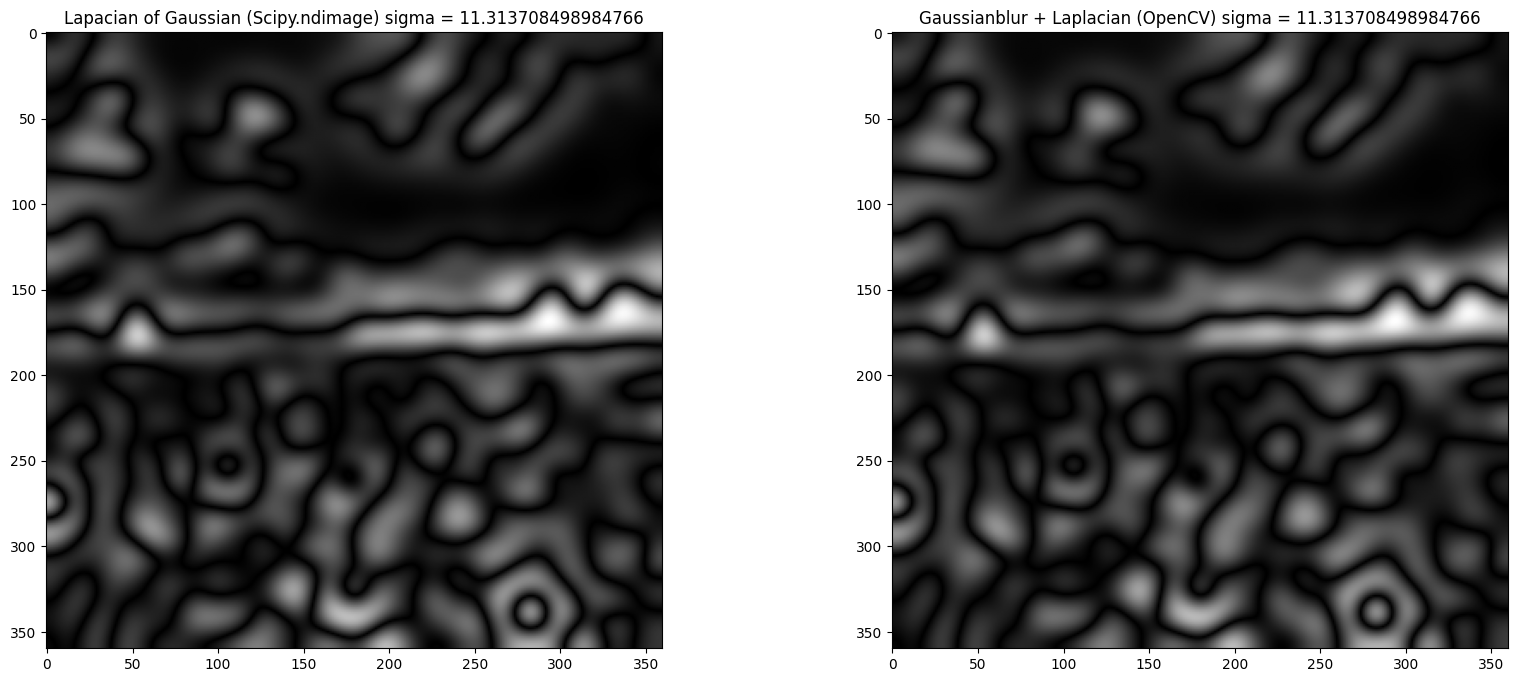

Detected blobs: 6446


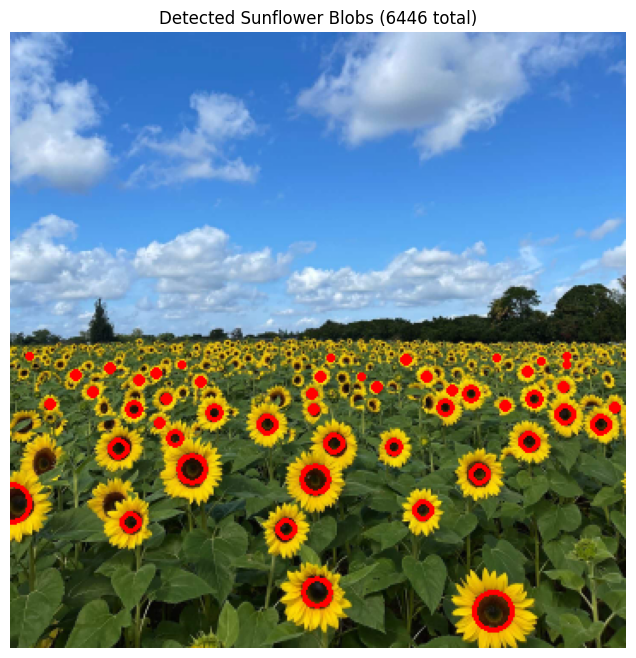

In [6]:
#Sigma values
min_sigma = 1
max_sigma = 20
num_scales = 8
k = np.sqrt(2)
sigmas = [min_sigma * (k ** i) for i in range(num_scales)]
print(sigmas)

#Scale space
rows, cols = sunflower_gray.shape
scale_space = np.zeros((num_scales, rows, cols), dtype=np.float32)
sc_sp = np.zeros((num_scales, rows, cols), dtype=np.float32)

for i, sigma in enumerate(sigmas):
  laplacian_of_gaussian = gaussian_laplace(sunflower_gray, sigma)
  scale_space[i] = (sigma**2) * np.abs(laplacian_of_gaussian)

  gaussian = cv.GaussianBlur(sunflower_gray, (0,0), sigma)
  laplacian = cv.Laplacian(gaussian, cv.CV_64F)
  lap_of_g = (sigma**2) * np.abs(laplacian)

  plt.figure(figsize=(20,8))
  plt.subplot(1,2,1)
  plt.imshow(scale_space[i], cmap='gray')
  plt.title(f'Lapacian of Gaussian (Scipy.ndimage) sigma = {sigma}')

  plt.subplot(1,2,2)
  plt.imshow(lap_of_g, cmap='gray')
  plt.title(f'Gaussianblur + Laplacian (OpenCV) sigma = {sigma}')
  plt.show()


threshold = 0.03 * scale_space.max()
blobs = []

for i in range(num_scales):
  max_f = maximum_filter(scale_space[i], size=3)
  mask = (scale_space[i] == max_f) & (scale_space[i]>threshold)
  ys, xs = np.nonzero(mask)
  for y, x in zip(ys, xs):
    blobs.append((x, y, sigmas[i], scale_space[i, y, x]))

blobs = sorted(blobs, key=lambda b: b[3], reverse=True)
final = []

for x, y, s, val in blobs:
    r = np.sqrt(2) * s
    if all(np.hypot(x - fx, y - fy) > 0.5 * (r + np.sqrt(2) * fs) for fx, fy, fs, fv in final):
        final.append((x, y, s, val))

print(f"Detected blobs: {len(final)}")

out = sunflower_img.copy()
# show top 50 blobs
for x, y, s, val in final[:50]:  
    r = int(np.sqrt(2) * s)
    cv.circle(out, (int(x), int(y)), r, (0, 0, 255), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv.cvtColor(out, cv.COLOR_BGR2RGB))
plt.title(f"Detected Sunflower Blobs ({len(final)} total)")
plt.axis('off')
plt.show()


In [7]:
cv.imwrite('blob deteced image.png', out)

True

4805
Detected blobs: 1251


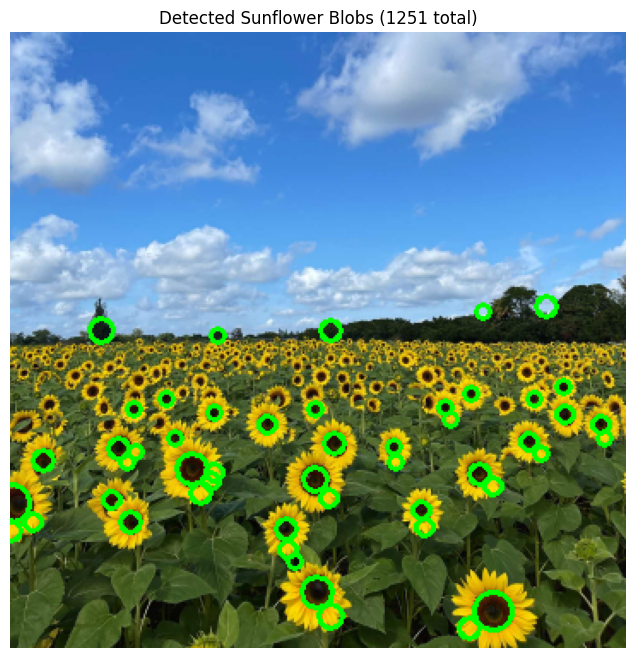

In [9]:
"""
Simple Blob Detection using Laplacian of Gaussian (LoG)
Detects circular blobs (sunflowers) in the image
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace, maximum_filter

# 1. Load and preprocess image
img = cv2.imread('the_berry_farms_sunflower_field.jpeg', cv2.IMREAD_REDUCED_COLOR_4)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32) / 255.0

# 2. Define sigma range (scale levels)
min_sigma, max_sigma, num_scales = 3, 25, 12
k = (max_sigma / min_sigma) ** (1 / (num_scales - 1))
sigmas = [min_sigma * (k ** i) for i in range(num_scales)]

# 3. Build scale-space using LoG (scale-normalized)
scale_space = np.zeros((num_scales, *gray.shape), dtype=np.float32)
for i, s in enumerate(sigmas):
    log_resp = gaussian_laplace(gray, sigma=s)
    scale_space[i] = (s ** 2) * np.abs(log_resp)

# 4. Find local maxima in scale-space
threshold = 0.03 * scale_space.max()
blobs = []
for i in range(num_scales):
    max_f = maximum_filter(scale_space[i], size=3)
    mask = (scale_space[i] == max_f) & (scale_space[i] > threshold)
    ys, xs = np.nonzero(mask)
    for y, x in zip(ys, xs):
        blobs.append((x, y, sigmas[i], scale_space[i, y, x]))

# 5. Remove overlapping blobs (keep strongest)
blobs = sorted(blobs, key=lambda b: b[3], reverse=True)

print(len(blobs))
final = []
for x, y, s, val in blobs:
    r = np.sqrt(2) * s
    if all(np.hypot(x - fx, y - fy) > 0.5 * (r + np.sqrt(2) * fs) for fx, fy, fs, fv in final):
        final.append((x, y, s, val))

print(f"Detected blobs: {len(final)}")

# 6. Draw detected blobs on the image
out = img.copy()
for x, y, s, val in final[:50]:  # show top 50 blobs
    r = int(np.sqrt(2) * s)
    cv2.circle(out, (int(x), int(y)), r, (0, 255, 0), 2)

# 7. Display results
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.title(f"Detected Sunflower Blobs ({len(final)} total)")
plt.axis('off')
plt.show()


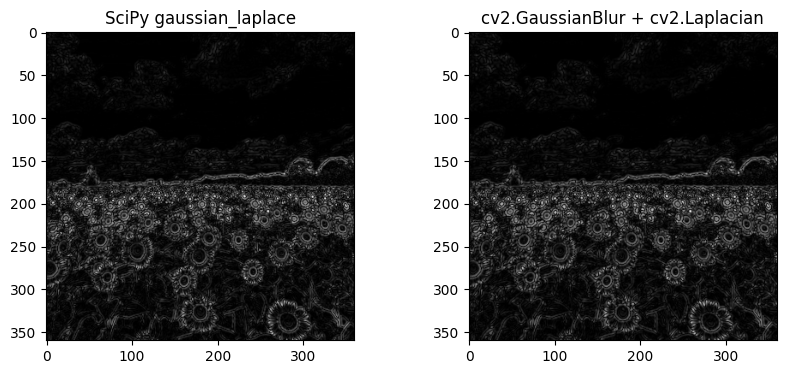

In [10]:
# Method 1: SciPy LoG
log_scipy = gaussian_laplace(sunflower_gray, sigma=1)

# Method 2: OpenCV Gaussian + Laplacian
blur = cv.GaussianBlur(sunflower_gray, (0,0), 1)
lap = cv.Laplacian(blur, cv.CV_64F)

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(np.abs(log_scipy), cmap='gray'); plt.title('SciPy gaussian_laplace')
plt.subplot(1,2,2); plt.imshow(np.abs(lap), cmap='gray'); plt.title('cv2.GaussianBlur + cv2.Laplacian')
plt.show()

**Laplacian of Gaussian** 
   
The Laplacian of Gaussian is given by,  
  
 $\nabla^2 G(x, y) = \frac{\partial^2 G}{\partial x^2} + \frac{\partial^2 G}{\partial y^2}$.  
   
 $LoG(x,y) =\frac{1}{\pi \sigma^4}
\left[
1 - \frac{x^2 + y^2}{2\sigma^2}
\right]
e^{-\frac{x^2 + y^2}{2\sigma^2}}$




#### **02. Line and Circle Fitting**

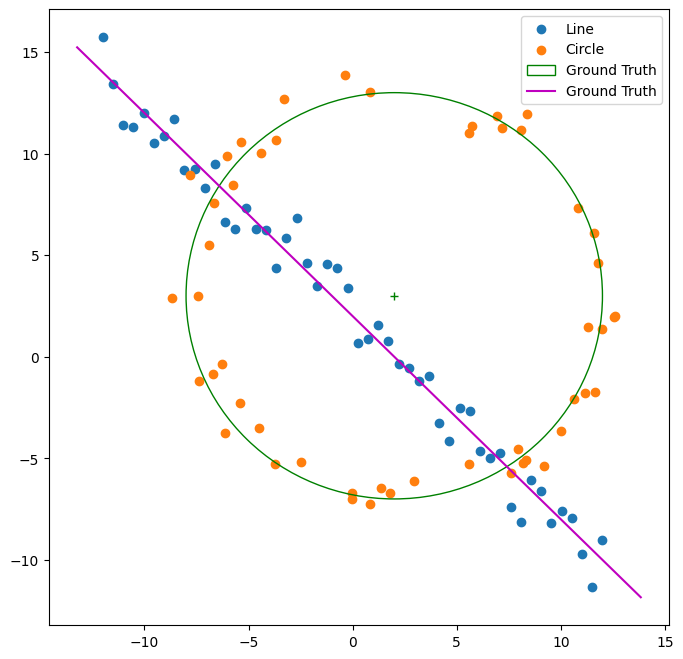

In [6]:
import numpy as np
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
#import tikzplotlib

# np.random.seed(0)
N= 100
half_n = N//2
r = 10
x0_gt , y0_gt = 2, 3 # Center
s = r/16
t = np.random.uniform(0, 2*np.pi , half_n)
n = s*np.random.randn(half_n)
x, y = x0_gt + (r + n)*np.cos(t), y0_gt + (r + n)*np.sin(t)
X_circ = np.hstack((x.reshape(half_n ,1) , y.reshape(half_n ,1)))
s = 1.
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m*x + b + s*np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n ,1) , y.reshape(half_n ,1)))
X = np.vstack((X_circ , X_line )) # All points

fig , ax = plt.subplots(1,1, figsize =(8 ,8))
ax. scatter (X_line [: ,0] , X_line [: ,1] , label= 'Line' )
ax. scatter ( X_circ [: ,0] , X_circ [: ,1] , label= 'Circle' )
circle_gt = plt . Circle ((x0_gt ,y0_gt) , r , color= 'g' , fill=False , label='Ground Truth')
ax. add_patch( circle_gt )
ax. plot (( x0_gt) , (y0_gt) , '+ ' , color= 'g' )
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m*x_ + b
plt . plot (x_ , y_, color= 'm' , label='Ground Truth')
plt . legend ()

**1) Line fitting using RANSAC**

Line model: a=-0.709, b=-0.705, d=-1.433
Line inliers: 60 / 100


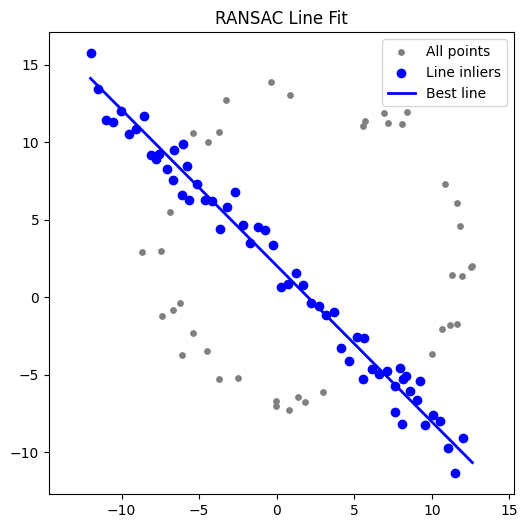

In [ ]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt
np.random.seed(0)


def fit_line_from_points(p1, p2):
    v = p2 - p1
    n = np.array([-v[1], v[0]])
    norm = np.linalg.norm(n)
    if norm == 0: return None
    a,b = n / norm
    d = a*p1[0] + b*p1[1]
    return a,b,d

def ransac_line(X, n_iter=2000, thresh=1.5):
    best_model, best_inliers = None, []
    N = len(X)
    for _ in range(n_iter):
        ids = np.random.choice(N, 2, replace=False)
        a,b,d = fit_line_from_points(X[ids[0]], X[ids[1]])
        dist = np.abs(a*X[:,0] + b*X[:,1] - d)
        inliers = np.where(dist < thresh)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a,b,d)
    return best_model, best_inliers


# Run line RANSAC
(a,b,d), inliers_line = ransac_line(X)
print(f"Line model: a={a:.3f}, b={b:.3f}, d={d:.3f}")
print(f"Line inliers: {len(inliers_line)} / {len(X)}")

# Plot result
plt.figure(figsize=(6,6))
plt.scatter(X[:,0], X[:,1], s=15, c='gray', label='All points')
plt.scatter(X[inliers_line,0], X[inliers_line,1], c='blue', label='Line inliers')

# Draw the line
xx = np.linspace(X[:,0].min(), X[:,0].max(), 100)
yy = (d - a*xx)/b
plt.plot(xx, yy, 'b-', lw=2, label='Best line')
plt.axis('equal'); plt.legend(); plt.title("RANSAC Line Fit")
plt.show()

Circle model: x0=2.358, y0=3.316, r=9.806
Circle inliers: 40 / 40


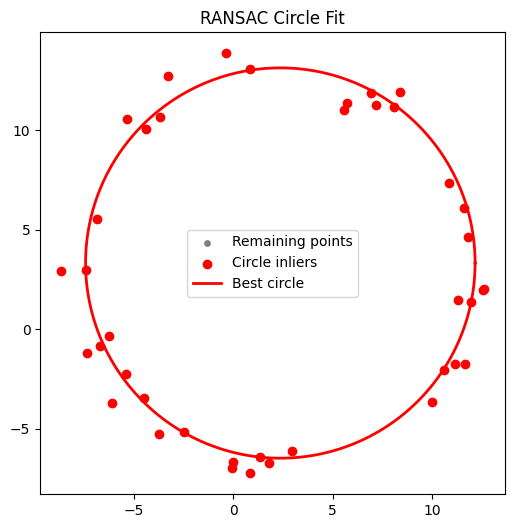

In [10]:
def circle_from_3pts(p1,p2,p3):
    A = np.array([
        [2*(p2[0]-p1[0]), 2*(p2[1]-p1[1])],
        [2*(p3[0]-p1[0]), 2*(p3[1]-p1[1])]
    ])
    b = np.array([
        p2[0]**2+p2[1]**2 - p1[0]**2 - p1[1]**2,
        p3[0]**2+p3[1]**2 - p1[0]**2 - p1[1]**2
    ])
    if np.linalg.matrix_rank(A) < 2:
        return None
    x0, y0 = np.linalg.solve(A, b)
    r = np.sqrt((p1[0]-x0)**2 + (p1[1]-y0)**2)
    return x0, y0, r

def ransac_circle(X, n_iter=2000, thresh=1.5):
    best_model, best_inliers = None, []
    N = len(X)
    for _ in range(n_iter):
        ids = np.random.choice(N, 3, replace=False)
        model = circle_from_3pts(X[ids[0]], X[ids[1]], X[ids[2]])
        if model is None: continue
        x0,y0,r = model
        d = np.abs(np.sqrt((X[:,0]-x0)**2 + (X[:,1]-y0)**2) - r)
        inliers = np.where(d < thresh)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (x0,y0,r)
    return best_model, best_inliers

# Remove line inliers
remaining = np.delete(X, inliers_line, axis=0)
(x0,y0,r), inliers_circle = ransac_circle(remaining)
print(f"Circle model: x0={x0:.3f}, y0={y0:.3f}, r={r:.3f}")
print(f"Circle inliers: {len(inliers_circle)} / {len(remaining)}")

# Plot result
plt.figure(figsize=(6,6))
plt.scatter(remaining[:,0], remaining[:,1], c='gray', s=15, label='Remaining points')
plt.scatter(remaining[inliers_circle,0], remaining[inliers_circle,1], c='red', label='Circle inliers')

theta = np.linspace(0, 2*np.pi, 200)
plt.plot(x0 + r*np.cos(theta), y0 + r*np.sin(theta), 'r-', lw=2, label='Best circle')
plt.axis('equal'); plt.legend(); plt.title("RANSAC Circle Fit")
plt.show()

Line model: a=0.721, b=0.693, d=1.557
Line inliers: 52 / 100
Circle model: x0=2.326, y0=2.813, r=9.879
Circle inliers: 48 / 48


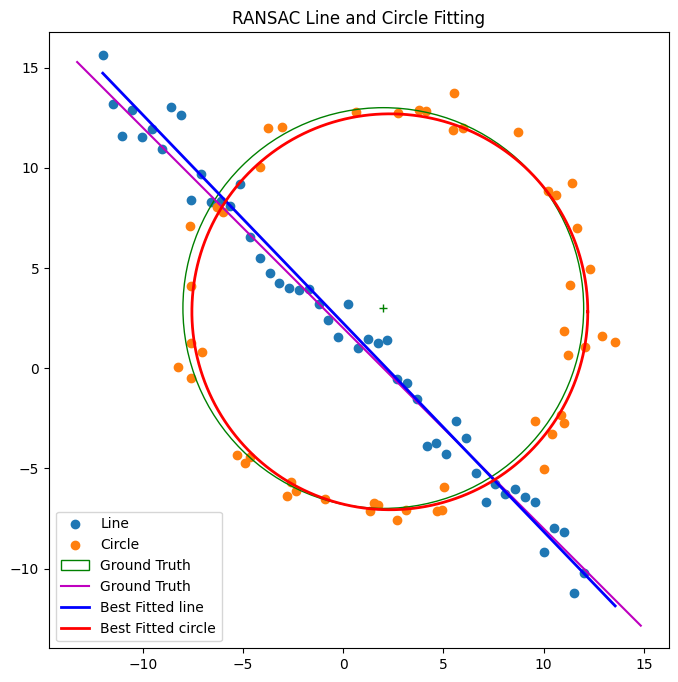

In [13]:
import numpy as np
from scipy.optimize import minimize
from scipy import linalg
import matplotlib.pyplot as plt
#import tikzplotlib

# np.random.seed(0)
N= 100
half_n = N//2
r = 10
x0_gt , y0_gt = 2, 3 # Center
s = r/16
t = np.random.uniform(0, 2*np.pi , half_n)
n = s*np.random.randn(half_n)
x, y = x0_gt + (r + n)*np.cos(t), y0_gt + (r + n)*np.sin(t)
X_circ = np.hstack((x.reshape(half_n ,1) , y.reshape(half_n ,1)))
s = 1.
m, b = -1, 2
x = np.linspace(-12, 12, half_n)
y = m*x + b + s*np.random.randn(half_n)
X_line = np.hstack((x.reshape(half_n ,1) , y.reshape(half_n ,1)))
X = np.vstack((X_circ , X_line )) # All points

fig , ax = plt.subplots(1,1, figsize =(8 ,8))
ax. scatter (X_line [: ,0] , X_line [: ,1] , label= 'Line' )
ax. scatter ( X_circ [: ,0] , X_circ [: ,1] , label= 'Circle' )
circle_gt = plt . Circle ((x0_gt ,y0_gt) , r , color= 'g' , fill=False , label='Ground Truth')
ax. add_patch( circle_gt )
ax. plot (( x0_gt) , (y0_gt) , '+ ' , color= 'g' )
x_min, x_max = ax.get_xlim()
x_ = np.array([x_min, x_max])
y_ = m*x_ + b
plt . plot (x_ , y_, color= 'm' , label='Ground Truth')
plt . legend ()


def fit_line_from_points(p1, p2):
    v = p2 - p1
    n = np.array([-v[1], v[0]])
    norm = np.linalg.norm(n)
    if norm == 0: return None
    a,b = n / norm
    d = a*p1[0] + b*p1[1]
    return a,b,d

def ransac_line(X, n_iter=2000, thresh=1.5):
    best_model, best_inliers = None, []
    N = len(X)
    for _ in range(n_iter):
        ids = np.random.choice(N, 2, replace=False)
        a,b,d = fit_line_from_points(X[ids[0]], X[ids[1]])
        dist = np.abs(a*X[:,0] + b*X[:,1] - d)
        inliers = np.where(dist < thresh)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (a,b,d)
    return best_model, best_inliers


# Run line RANSAC
(a,b,d), inliers_line = ransac_line(X)
print(f"Line model: a={a:.3f}, b={b:.3f}, d={d:.3f}")
print(f"Line inliers: {len(inliers_line)} / {len(X)}")

# Draw the line
xx = np.linspace(X[:,0].min(), X[:,0].max(), 100)
yy = (d - a*xx)/b
plt.plot(xx, yy, 'b-', lw=2, label='Best Fitted line')
plt.axis('equal'); plt.legend()


def circle_from_3pts(p1,p2,p3):
    A = np.array([
        [2*(p2[0]-p1[0]), 2*(p2[1]-p1[1])],
        [2*(p3[0]-p1[0]), 2*(p3[1]-p1[1])]
    ])
    b = np.array([
        p2[0]**2+p2[1]**2 - p1[0]**2 - p1[1]**2,
        p3[0]**2+p3[1]**2 - p1[0]**2 - p1[1]**2
    ])
    if np.linalg.matrix_rank(A) < 2:
        return None
    x0, y0 = np.linalg.solve(A, b)
    r = np.sqrt((p1[0]-x0)**2 + (p1[1]-y0)**2)
    return x0, y0, r

def ransac_circle(X, n_iter=2000, thresh=1.5):
    best_model, best_inliers = None, []
    N = len(X)
    for _ in range(n_iter):
        ids = np.random.choice(N, 3, replace=False)
        model = circle_from_3pts(X[ids[0]], X[ids[1]], X[ids[2]])
        if model is None: continue
        x0,y0,r = model
        d = np.abs(np.sqrt((X[:,0]-x0)**2 + (X[:,1]-y0)**2) - r)
        inliers = np.where(d < thresh)[0]
        if len(inliers) > len(best_inliers):
            best_inliers = inliers
            best_model = (x0,y0,r)
    return best_model, best_inliers

# Remove line inliers
remaining = np.delete(X, inliers_line, axis=0)
(x0,y0,r), inliers_circle = ransac_circle(remaining)
print(f"Circle model: x0={x0:.3f}, y0={y0:.3f}, r={r:.3f}")
print(f"Circle inliers: {len(inliers_circle)} / {len(remaining)}")


theta = np.linspace(0, 2*np.pi, 200)
plt.plot(x0 + r*np.cos(theta), y0 + r*np.sin(theta), 'r-', lw=2, label='Best Fitted circle')
plt.axis('equal'); plt.legend(); plt.title("RANSAC Line and Circle Fitting")

plt.show()

#### **03 